In [1]:
!pip install wandb

In [6]:
import wandb
from google.colab import userdata
import os
os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')


In [7]:
wandb.init(project="Lab_2_Tests", entity="ertveh-4-lule-university-of-technology")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ertveh-4 (ertveh-4-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb


# Hyperparameters
mb_size = 64
Z_dim = 1000
h_dim = 128
lr = 1e-3
Y_dim = 10 # https://github.com/wiseodd/generative-models/blob/master/GAN/conditional_gan/cgan_pytorch.py#L35
# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the 28x28 image to 784
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

X_dim = 784  # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, x_dim, y_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim+y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z,y):
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc1(z))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, h_dim,y_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim+y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x,y):
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out



# Training
def cGANTraining(G, D, loss_fn, train_loader):
    G.train()
    D.train()

    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)

    for it, (X_real, labels) in enumerate(t):
        # Prepare real data
        X_real = X_real.float().to(device)
        y = torch.zeros(X_real.size(0), Y_dim).to(device)
        y[torch.arange(X_real.size(0)), labels] = 1
        # Sample noise and labels
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ================= Train Discriminator =================
        G_sample = G(z,y)
        D_real = D(X_real,y)
        D_fake = D(G_sample.detach(),y)

        D_loss_real = loss_fn(D_real, ones_label)
        D_loss_fake = loss_fn(D_fake, zeros_label)
        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        G_sample = G(z,y)
        D_fake = D(G_sample,y)

        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    # ================= Logging =================
    D_loss_real_avg = D_loss_real_total / len(train_loader)
    D_loss_fake_avg = D_loss_fake_total / len(train_loader)
    D_loss_avg = D_loss_real_avg + D_loss_fake_avg
    G_loss_avg = G_loss_total / len(train_loader)

    wandb.log({
        "D_loss_real": D_loss_real_avg,
        "D_loss_fake": D_loss_fake_avg,
        "D_loss": D_loss_avg,
        "G_loss": G_loss_avg
    })

    return G, D, G_loss_avg, D_loss_avg



def save_sample(G, epoch, mb_size, Z_dim,Y_dim, target_digit):
    out_dir = "out_vanila_CGAN"
    G.eval()
    with torch.no_grad():
        z = torch.randn(mb_size, Z_dim).to(device)
        y = torch.zeros(mb_size, Y_dim).to(device)
        y[:, target_digit] = 1
        samples = G(z, y).detach().cpu().numpy()[:16]

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis('off')
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect('equal')
        plt.imshow(sample.reshape(28, 28), cmap='Greys_r')

    if not os.path.exists(f'{out_dir}'):
        os.makedirs(f'{out_dir}')

    plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
    plt.close(fig)



########################### Main #######################################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models
G = Generator(Z_dim, h_dim, X_dim,Y_dim).to(device)
D = Discriminator(X_dim, h_dim, Y_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss function
def my_bce_loss(preds, targets):
    return F.binary_cross_entropy(preds, targets)

#loss_fn = nn.BCEWithLogitsLoss() ## task 2
loss_fn = my_bce_loss #task 1-3

if wandb_log:
    wandb.init(project="Lab_2_Tests", entity="ertveh-4-lule-university-of-technology",name="task3_50ep", reinit="finish_previous")

    # Log hyperparameters
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')  # Initialize best generator loss
save_dir = 'checkpoints'
os.makedirs(save_dir, exist_ok=True)

#Train epochs
epochs = 50 ## setting them up manually TODO: move this to a more systematic way

for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg= cGANTraining(G, D, loss_fn, train_loader)

    print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, mb_size, Z_dim,Y_dim, target_digit=3)


# Inference
# G.load_state_dict(torch.load('checkpoints/G_best.pth'))
# G.eval()

# save_sample(G, "best", mb_size, Z_dim)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.38MB/s]


100%|██████████| 938/938 [00:12<00:00, 72.26it/s]


epoch0; D_loss: 0.0668; G_loss: 7.3264
Saved Best Models at epoch 0 | G_loss: 7.3264


100%|██████████| 938/938 [00:12<00:00, 76.72it/s]


epoch1; D_loss: 0.0162; G_loss: 7.7263


...

epoch47; D_loss: 0.7229; G_loss: 2.1650


100%|██████████| 938/938 [00:12<00:00, 75.82it/s]


epoch48; D_loss: 0.7250; G_loss: 2.1706


100%|██████████| 938/938 [00:12<00:00, 77.22it/s]


epoch49; D_loss: 0.7193; G_loss: 2.1681


Trying a few digits to test CGAN:

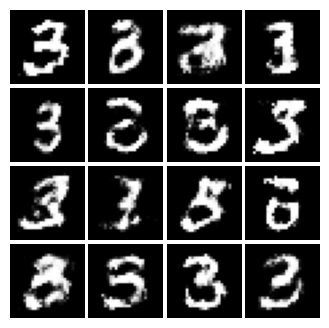

In [21]:
G.load_state_dict(torch.load('checkpoints/G_best.pth'))
G.eval()

save_sample(G, "best_3", mb_size, Z_dim,Y_dim,target_digit=3)
from IPython.display import Image
Image('out_vanila_CGAN/best_3.png')


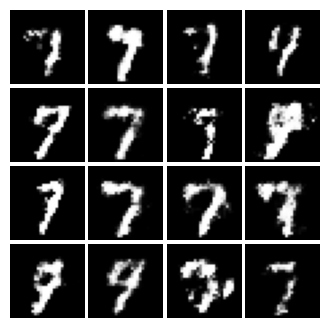

In [22]:
save_sample(G, "best_7", mb_size, Z_dim,Y_dim,target_digit=7)
from IPython.display import Image
Image('out_vanila_CGAN/best_7.png')


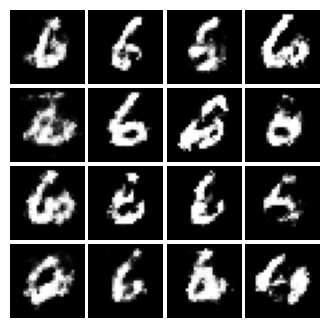

In [23]:
save_sample(G, "best_6", mb_size, Z_dim,Y_dim,target_digit=6)
from IPython.display import Image
Image('out_vanila_CGAN/best_6.png')

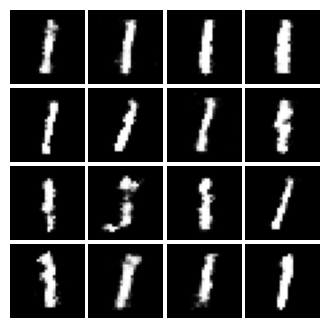

In [24]:
save_sample(G, "best_1", mb_size, Z_dim,Y_dim,target_digit=1)
from IPython.display import Image
Image('out_vanila_CGAN/best_1.png')

# Conclusion

It looks like CGAN performs better than GAN, and knows the classes.  (to be commented more)

In [11]:
from google.colab import files
import shutil
shutil.make_archive('out_vanila_CGAN_Task3_50epoch', 'zip', 'out_vanila_CGAN')
files.download('out_vanila_CGAN_Task3_50epoch.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
shutil.make_archive('checkpoints_CGAN_Task3_50epoch', 'zip', 'checkpoints')
files.download('checkpoints_CGAN_Task3_50epoch.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>